
Three files will be analyzed and their data extracted to make a comparison between the input data and the TolTEC camera observations, since the objective will be to know how good the instrument is. With .fits, srl.FITS and .csv endings. The first corresponds to observations from the TolTEC camera that will result in an image. The second is a binary table. The third is a table containing the different fluxes at a given wavelength.

### The following libraries are required 
- sys
- ToltecSignalFits
- InputModelFits
- BdsfCat
- SimuInputSources
- CatalogMatch

The sys. path. append() is a built-in function of the sys module in Python that can be used with path variables to add a specific path for an interpreter to search.

In [7]:
import sys
sys.path.append('toltec_pybdsf_scripts-main')
from ToltecSignalFits import ToltecSignalFits
from InputModelFits import InputModelFits
from BdsfCat import BdsfCat
from SimuInputSources import SimuInputSources
from CatalogMatch import CatalogMatch

The command ls lists directory files for the current directory. In this case it is used to make sure that the toltec_pybdsf_scripts-main folder does indeed contain the toltec_simu_a1100_filtered.fits file. 

In [8]:
ls

Una_fuente.ipynb                 sq0.01.pybdsm.srl.FITS
a1400.ipynb                      squareCat_0.01mJy.csv
leer_fits.ipynb                  toltec.py
leer_fluj.ipynb                  toltec_pybdsf_scripts-main/
prog1.py                         toltec_simu_a1100_filtered.fits
sources.csv                      toltec_simu_a1400_filtered.fits


In [9]:
ls toltec_pybdsf_scripts-main 

AstropyTab.py              ToltecSignalFits.py
BdsfCat.py                 __pycache__/
CatalogMatch.py            identifySources.py
InputModelFits.py          subtractSourcesExample.py
README.md                  toltec_pybdsf_scripts/
SimuInputSources.py



### To read a .fits file we can use ToltecSignalFits
It is used as follows

fun_nom=ToltecSignalFits("path to file", wavelength).

Then, to discard the edges of the image, setWeightCut() is used, since the central areas have more weight. The wavelength to use is a1100. Note that the file contains several extensions, so when plotting, we need to specify which one we want to see.

['./toltec_simu_a1100_filtered.fits']
Fits file found: ./toltec_simu_a1100_filtered.fits


<WCSAxesSubplot:>

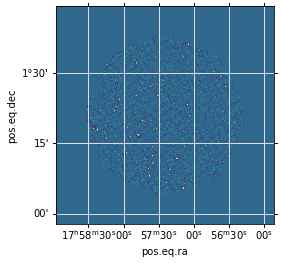

In [10]:
tf1p1 = ToltecSignalFits("./", array='a1100') # To load a TolTEC observation, in this case a1100
tf1p1.setWeightCut(0.5) # if the weight is less than 0.5 it is not taken
tf1p1.plotImage('signal_I',vmin=-0.5 , vmax=1) # shows the image of the extension signal_I

#### SimuInputSources
To visualize the way in which the flux is recovered, we will make a comparison between the input flux and the observed flux. To read the input flux we use SimuInputSources class.

This class has a method (inphotPS) to perform PSF photometry at the input sources 
coordinates using a ToltecSignalFits object. Photometry provides a direct measure of the flux of energy received from celestial objects over a range of wavelengths.
A maximum flux is set, therefore it will only take the sources that have that limit so that it does not use all the sources

fun_nom=SimuInputSources("file name .csv",fluxLimit=fluxLimit)







/Users/mariajosemejiamorales/Desktop/praticas/toltec_pybdsf_scripts-main/ToltecSignalFits.py:574: RuntimeWarning: divide by zero encountered in power
  noise=(tfipj.getMap('weight_I'))**(-0.5)*flux_fact


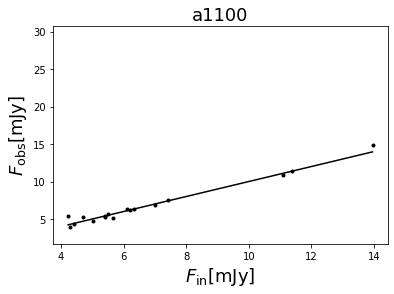

In [11]:
  fluxLimit = 1   # To take sources of 1 milli janskin
  sq = SimuInputSources("squareCat_0.01mJy.csv", fluxLimit=fluxLimit ) # To read the file  
  inputtab_phot=sq.inphotPS(tf1p1) # To compare TolTEC observations with input data sq 
  inputtab_phot.plotInPhot() # show the graph

#### BdsfCat y CatalogMatch
BdsfCat is a tool used to extract data from srl.FITS files. This class can be combined with ToltecSignalFits class to extract point source photometry using PSF fitting.

CatalogMatch manages matches between data extracted from a SimuInputSources and a BdsfCat.
The output is a set of dictionaries of matches, false detections, and unmatched input sources.
At the end, comparisons between photometry and input matched fluxes will be plotted.

/Users/mariajosemejiamorales/Desktop/praticas/toltec_pybdsf_scripts-main/ToltecSignalFits.py:574: RuntimeWarning: divide by zero encountered in power
  noise=(tfipj.getMap('weight_I'))**(-0.5)*flux_fact


[0]
[1]
[2]
[]
[3]
[4]
[5]
[6]
[7]
[8]
[9]
[10]
[11]
[]
[12]
[]
[13]
[14]
[]
[15]
[16]
[]
22 22 22


/Users/mariajosemejiamorales/Desktop/praticas/toltec_pybdsf_scripts-main/CatalogMatch.py:333: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  axs[0].set_ylim(min(np.array(fluxPSF)*0.7),max(np.array(fluxPSF)*1.3))
/Users/mariajosemejiamorales/Desktop/praticas/toltec_pybdsf_scripts-main/CatalogMatch.py:339: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  axs[1].set_ylim(min(np.array(fluxPSF)*0.8),max(np.array(fluxPSF)*1.2))


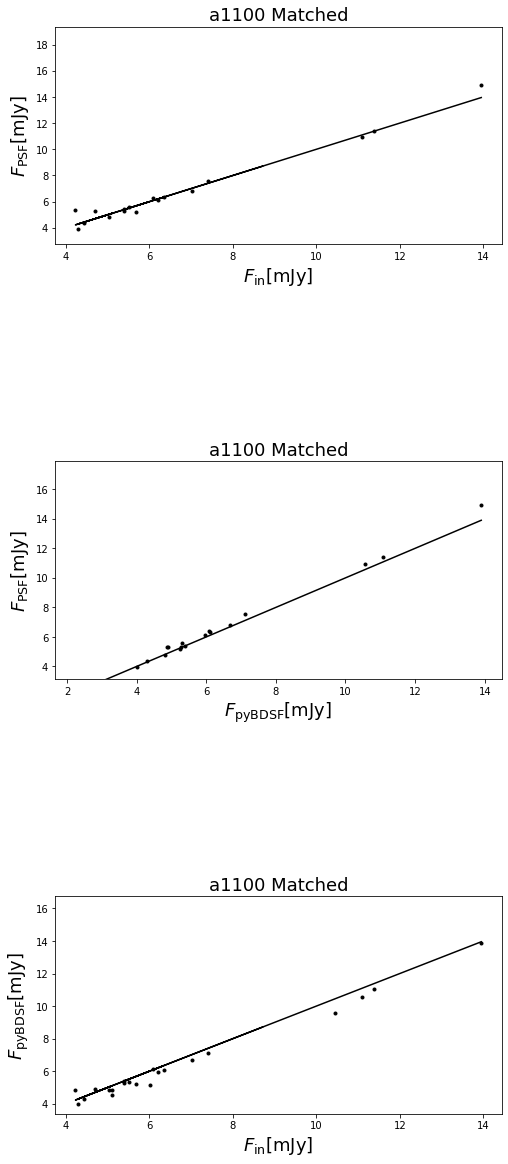

In [14]:
pb = BdsfCat("/Users/mariajosemejiamorales/Desktop/praticas/sq0.01.pybdsm.srl.FITS") # To read the srl.FITS file
cm = CatalogMatch(pb, sq) # To manage matches between pb and sq
tab_phot=tf1p1.photPS(pb) # to extract point source photometry  
cm.plotMatch(tab_phot) # print comparisons of tab_phot and pb and sq